# AMS Meter Failure Analysis — Starter Notebook

End-to-end runnable narrative for finding patterns that precede non-com events
on AMS meters. This notebook strings together:

1. **Load** your event table and meter table (synthetic stub data is generated
   below so the notebook runs end-to-end out of the box — replace with your
   real data where marked).
2. **Pull** daily weather and severe-storm events from public APIs
   (`weather_pull.py`).
3. **Run** the prior-N events analysis with a matched-meter random-timestamp
   control (`prior_n_events.py`).
4. **Compute** the if-then funnel statistics (the boss-deck headlines).
5. **Generate** the visualizations (`viz.py`).
6. **Break out** failure rates by hardware model, install age, collector,
   transformer (`hardware_lifecycle.py`).

Sections marked **REPLACE WITH REAL DATA** are where you point this at your
production tables.


## Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

# Project modules (all in the same folder as this notebook)
from prior_n_events import (
    attach_prior_n_events, summarize_prior_composition,
    build_random_control_anchors, compare_prior_compositions,
    cohort_followup, run_full_prior_n_analysis,
)
from viz import (
    plot_failure_anatomy_timeline, plot_pre_failure_signature,
    plot_hardware_model_bar, plot_county_choropleth,
    plot_calendar_heatmap, plot_prior3_composition_bar,
)
from hardware_lifecycle import (
    non_com_rate_by_hardware_model, non_com_rate_by_collector,
    non_com_rate_by_transformer, non_com_rate_by_install_age,
    hardware_model_x_age, time_to_first_failure,
)

OUTPUT_DIR = Path('./figures')
OUTPUT_DIR.mkdir(exist_ok=True)


## Step 1: Load the event and meter tables

> **REPLACE WITH REAL DATA**
> Replace the synthetic generator below with your real loads:
> ```python
> events = pd.read_parquet('s3://oncor/events.parquet')
> meters = pd.read_parquet('s3://oncor/meters.parquet')
> ```
>
> Required columns:
> - `events`: `meter_id`, `event_date`, `event_type` (and optionally
>   `hardware_model` etc., though it's cleaner to keep meter attributes in
>   the meter table)
> - `meters`: `meter_id`, `hardware_model`, `collector`, `transformer`,
>   `install_date`, `lat`, `lon`, `county_fips` (use
>   `weather_pull.assign_county_fips` to add the last one)


In [2]:
# === SYNTHETIC STUB DATA — REPLACE WITH REAL LOADS ===
rng = np.random.default_rng(42)

N_METERS = 500
N_FAILED = 120

# A Texas-ish bounding box
lat_lo, lat_hi = 30.5, 33.5
lon_lo, lon_hi = -99.0, -95.5

hardware_models = ['ModelA-v1', 'ModelA-v2', 'ModelB', 'ModelC', 'ModelD-legacy']
hardware_weights = [0.35, 0.25, 0.20, 0.15, 0.05]
# Inject a hardware-driven failure signal: ModelD-legacy fails 5x more often
model_failure_multiplier = {'ModelA-v1': 1.0, 'ModelA-v2': 0.8, 'ModelB': 1.2,
                            'ModelC': 1.0, 'ModelD-legacy': 5.0}

meters = pd.DataFrame({
    'meter_id': [f'M{i:05d}' for i in range(N_METERS)],
    'hardware_model': rng.choice(hardware_models, size=N_METERS, p=hardware_weights),
    'collector':   [f'COL-{i:04d}' for i in rng.integers(0, 80, size=N_METERS)],
    'transformer': [f'XFR-{i:05d}' for i in rng.integers(0, 200, size=N_METERS)],
    'install_date': pd.to_datetime('2010-01-01') + pd.to_timedelta(
        rng.integers(0, 5500, size=N_METERS), unit='D'),
    'lat': rng.uniform(lat_lo, lat_hi, size=N_METERS),
    'lon': rng.uniform(lon_lo, lon_hi, size=N_METERS),
})

# Pick failed meters with hardware-bias
weights = meters['hardware_model'].map(model_failure_multiplier).values
weights = weights / weights.sum()
failed_meter_idx = rng.choice(N_METERS, size=N_FAILED, replace=False, p=weights)
failed_meters = meters.iloc[failed_meter_idx]['meter_id'].values

# Generate baseline events for all meters
records = []
start, end = pd.Timestamp('2024-01-01'), pd.Timestamp('2025-12-31')
horizon_days = (end - start).days
for mid in meters['meter_id']:
    for _ in range(rng.poisson(8)):
        records.append({'meter_id': mid,
                        'event_date': start + pd.Timedelta(days=int(rng.integers(0, horizon_days))),
                        'event_type': 'outage'})
    for _ in range(rng.poisson(5)):
        records.append({'meter_id': mid,
                        'event_date': start + pd.Timedelta(days=int(rng.integers(0, horizon_days))),
                        'event_type': 'weather_extreme'})
    for _ in range(rng.poisson(2)):
        records.append({'meter_id': mid,
                        'event_date': start + pd.Timedelta(days=int(rng.integers(0, horizon_days))),
                        'event_type': 'firmware_update'})

# Inject the planted signal: failed meters get extra outages in the 30 days
# before their non-com event
for mid in failed_meters:
    ncom_date = start + pd.Timedelta(days=int(rng.integers(horizon_days // 2, horizon_days)))
    burst_n = int(rng.integers(3, 6))
    for _ in range(burst_n):
        records.append({'meter_id': mid,
                        'event_date': ncom_date - pd.Timedelta(days=int(rng.integers(1, 25))),
                        'event_type': 'outage'})
    if rng.random() < 0.5:
        records.append({'meter_id': mid,
                        'event_date': ncom_date - pd.Timedelta(days=int(rng.integers(1, 30))),
                        'event_type': 'weather_extreme'})
    records.append({'meter_id': mid, 'event_date': ncom_date, 'event_type': 'non_com'})

events = (pd.DataFrame(records)
          .sort_values(['meter_id', 'event_date'])
          .reset_index(drop=True))
events['event_date'] = pd.to_datetime(events['event_date'])

print(f'Meters: {len(meters):,}')
print(f'Events: {len(events):,}')
print(events['event_type'].value_counts())


Meters: 500
Events: 8,138
event_type
outage             4473
weather_extreme    2550
firmware_update     995
non_com             120
Name: count, dtype: int64


## Step 2: Inventory the data

In [3]:
print('Date range:', events['event_date'].min(), '→', events['event_date'].max())
print()
print('Event type breakdown:')
print(events['event_type'].value_counts())
print()
print('Meters with at least one non-com:',
      events.loc[events['event_type'] == 'non_com', 'meter_id'].nunique(),
      f'({100 * events.loc[events["event_type"] == "non_com", "meter_id"].nunique() / len(meters):.1f}%)')


Date range: 2024-01-01 00:00:00 → 2025-12-30 00:00:00

Event type breakdown:
event_type
outage             4473
weather_extreme    2550
firmware_update     995
non_com             120
Name: count, dtype: int64

Meters with at least one non-com: 120 (24.0%)


## Step 3: (Optional) Pull weather + storm events

The first run hits the APIs and may take several minutes / hours depending on
how many unique 0.1° cells your meters bin to. After that, everything caches
to parquet under `./weather_cache/`, and re-runs are instant.

Uncomment the cell below when you want to actually pull weather. For the
notebook's first end-to-end run we'll skip it (the synthetic events already
include `weather_extreme` events for demonstration).


In [4]:
# from weather_pull import build_weather_features, assign_county_fips
#
# meters = assign_county_fips(meters, lat_col='lat', lon_col='lon',
#                              cache_dir='./weather_cache')
#
# weather_daily, storm_events = build_weather_features(
#     meters, lat_col='lat', lon_col='lon',
#     start_date='2021-01-01', end_date='2026-04-26',
#     cache_dir='./weather_cache',
# )
#
# # Promote storm events into the unified event table
# storm_meter_join = (
#     meters[['meter_id', 'county_fips']].merge(storm_events, on='county_fips')
#     [['meter_id', 'begin_date', 'event_type']]
#     .rename(columns={'begin_date': 'event_date'})
# )
# storm_meter_join['event_type'] = (
#     'storm_' + storm_meter_join['event_type'].str.lower()
#                                              .str.replace(' ', '_')
# )
# events = pd.concat([events, storm_meter_join], ignore_index=True)


## Step 4: Prior-N events analysis

For every non-com event, fetch the 3 events that immediately preceded it on
the same meter, then build a same-meter random-timestamp control and compare.
The lift columns are what answer "is this event type actually a precursor or
just common?"


In [5]:
result = run_full_prior_n_analysis(
    events,
    n=3,
    anchor_event_type='non_com',
    max_lookback_days=90,
    seed=42,
    verbose=True,
)
result['lift_table']


Attaching prior 3 events to each non_com ...
Building random-timestamp control on same meters ...


,non_com_pct_with_1,non_com_pct_of_slots,non_com_n,control_pct_with_1,control_pct_of_slots,control_n,lift_pct_with_1,lift_pct_of_slots
event_type,,,,,,,,
outage,70.0,87.5,120.0,52.5,58.6,120,1.33,1.49
weather_extreme,22.5,10.9,120.0,28.3,25.4,120,0.80,0.43
firmware_update,3.3,1.6,120.0,15.8,11.6,120,0.21,0.14
non_com,0.0,0.0,NaN,6.7,4.4,120,0.00,0.00


**How to read the lift table**

- `non_com_pct_with_1` — % of non-com events that had at least one of this
  event type in their prior-3 window.
- `control_pct_with_1` — same, for the matched random-timestamp control.
- `lift_pct_with_1` — ratio. >1 means over-represented before non-coms.
- `lift_pct_of_slots` — usually the cleaner number for common event types
  (where "at least 1" gets saturated).

A lift of 2.0 means an event type is twice as common before non-coms as in
matched non-failure windows. A lift of 8.0 means it's a strong precursor.


## Step 5: The if-then funnel — sweep the threshold

The cleanest single statistic for the boss deck. We sweep the outage-count
threshold to find a knee in the curve.


In [6]:
funnel_rows = []
for k in [1, 2, 3, 4, 5]:
    f = cohort_followup(
        events,
        lookback_event_type='outage',
        lookback_count_threshold=k,
        lookback_window_days=30,
        followup_event_type='non_com',
        followup_window_days=60,
    )
    funnel_rows.append({
        'threshold': f'>={k} outages in 30d',
        'n_meter_days_exposed': f['exposed_meter_days'],
        'exposed_followup_rate': f['exposed_followup_rate'],
        'unexposed_followup_rate': f['unexposed_followup_rate'],
        'lift': f['lift'],
        'headline': f['headline'],
    })
funnel_table = pd.DataFrame(funnel_rows)
funnel_table[['threshold', 'n_meter_days_exposed',
              'exposed_followup_rate', 'unexposed_followup_rate', 'lift']]


,threshold,n_meter_days_exposed,exposed_followup_rate,unexposed_followup_rate,lift
0,>=1 outages in 30d,2703,17.8%,3.5%,5.1x
1,>=2 outages in 30d,776,42.0%,4.7%,9.0x
2,>=3 outages in 30d,372,48.4%,6.3%,7.7x
3,>=4 outages in 30d,186,40.9%,7.5%,5.5x
4,>=5 outages in 30d,84,23.8%,8.1%,3.0x


In [7]:
# Pick the threshold with the cleanest combination of high lift and large n
print('Headline candidates for the deck:')
for row in funnel_rows:
    print(f"  • {row['headline']}  (n_exposed={row['n_meter_days_exposed']:,})")


Headline candidates for the deck:
  • Meters with 1+ outage events in the prior 30 days are 5.1x more likely to have a non_com event in the next 60 days.  (n_exposed=2,703)
  • Meters with 2+ outage events in the prior 30 days are 9.0x more likely to have a non_com event in the next 60 days.  (n_exposed=776)
  • Meters with 3+ outage events in the prior 30 days are 7.7x more likely to have a non_com event in the next 60 days.  (n_exposed=372)
  • Meters with 4+ outage events in the prior 30 days are 5.5x more likely to have a non_com event in the next 60 days.  (n_exposed=186)
  • Meters with 5+ outage events in the prior 30 days are 3.0x more likely to have a non_com event in the next 60 days.  (n_exposed=84)


## Step 6: Boss-deck visuals

Each visual is saved to `./figures/` as a PNG ready to drop into PowerPoint.


### 6a. Anatomy of a failure — per-meter event timeline

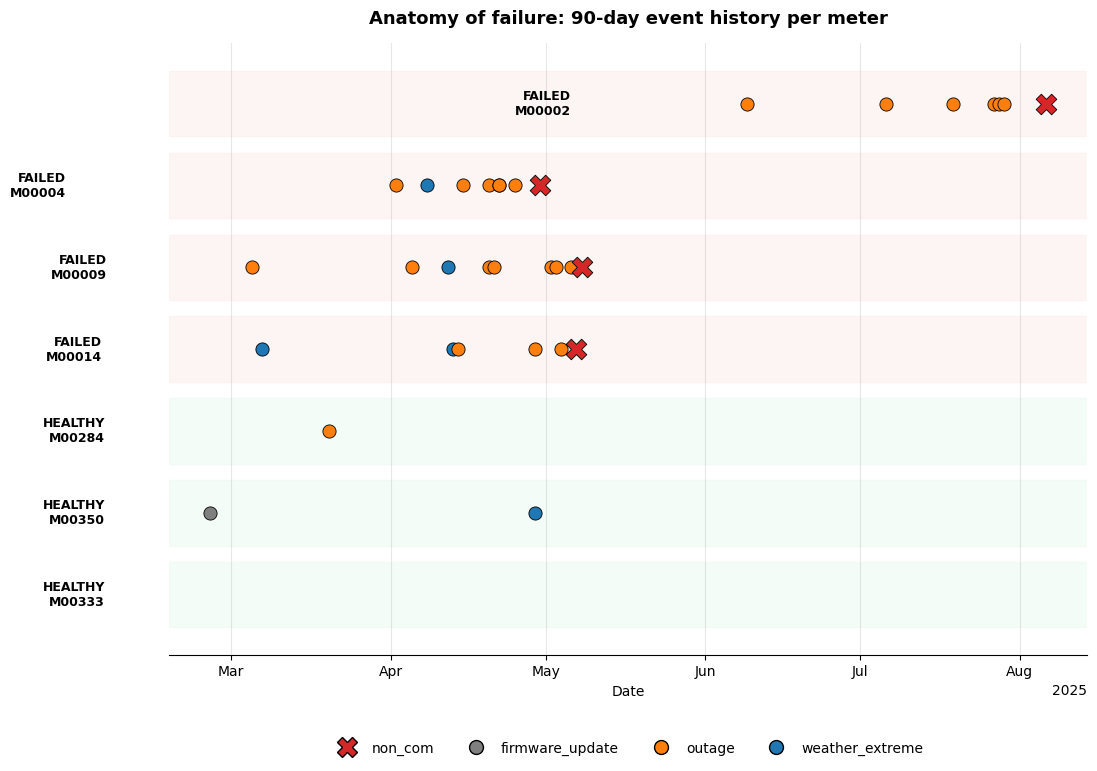

In [8]:
# Pick a few failed and a few healthy meters in the same period
failed_examples = events.loc[events['event_type'] == 'non_com', 'meter_id'].unique()[:4]
all_meter_ids = set(meters['meter_id'])
healthy_examples = list(all_meter_ids - set(events.loc[events['event_type'] == 'non_com', 'meter_id'].unique()))[:3]

fig = plot_failure_anatomy_timeline(
    events,
    failed_meter_ids=list(failed_examples),
    healthy_meter_ids=healthy_examples,
    window_days=90,
    output_path=OUTPUT_DIR / '01_anatomy_timeline.png',
)
plt.show()


### 6b. Pre-failure signature — aggregate event rate vs days before non-com

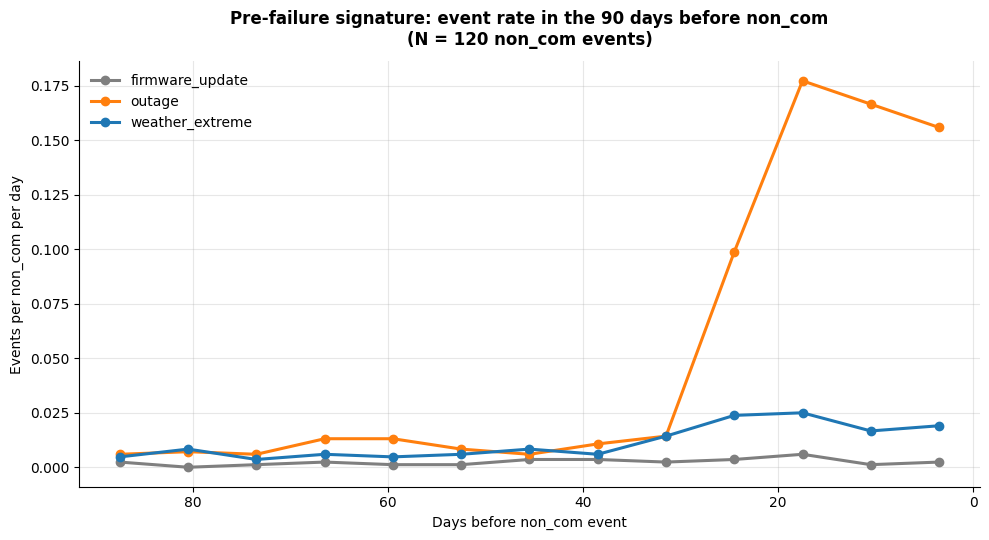

In [9]:
fig = plot_pre_failure_signature(
    events,
    anchor_event_type='non_com',
    window_days=90,
    bin_days=7,
    output_path=OUTPUT_DIR / '02_pre_failure_signature.png',
)
plt.show()


### 6c. Hardware-model bar — non-com rate per 1,000 meters

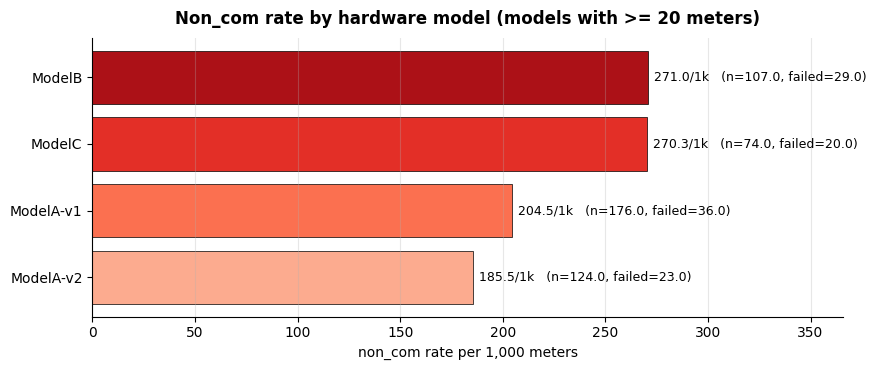

In [10]:
fig = plot_hardware_model_bar(
    meters, events,
    hardware_col='hardware_model',
    min_meters_per_model=20,
    output_path=OUTPUT_DIR / '03_hardware_model_bar.png',
)
plt.show()


### 6d. Texas county choropleth

Requires `geopandas`. Skipped for the synthetic stub run because the meter
table doesn't have `county_fips` populated. Once you've called
`assign_county_fips(meters, ...)` (see Step 3), uncomment to generate.


In [11]:
# fig = plot_county_choropleth(
#     meters, events,
#     county_fips_col='county_fips',
#     cache_dir='./weather_cache',
#     output_path=OUTPUT_DIR / '04_county_choropleth.png',
# )
# plt.show()


### 6e. Calendar heatmap — non-com counts by day of year

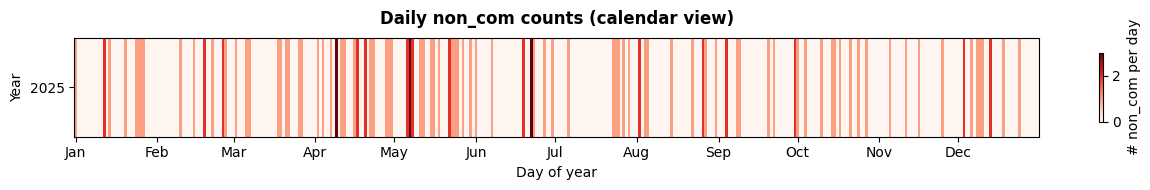

In [12]:
fig = plot_calendar_heatmap(
    events,
    anchor_event_type='non_com',
    output_path=OUTPUT_DIR / '05_calendar_heatmap.png',
)
plt.show()


### 6f. Prior-3 composition — actual non-com vs control

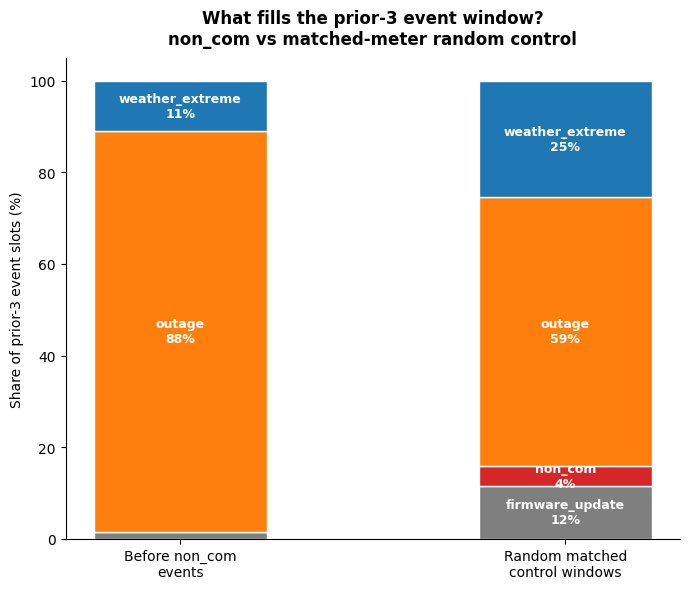

In [13]:
fig = plot_prior3_composition_bar(
    result['actual_summary'], result['control_summary'],
    actual_label='non_com', control_label='control',
    output_path=OUTPUT_DIR / '06_prior3_composition.png',
)
plt.show()


## Step 7: Hardware lifecycle breakouts

Where does the failure live? If one model or one collector accounts for most
of the non-coms, that's a more actionable finding than "weather correlates
with failure."


### 7a. Failure rate by hardware model

In [14]:
non_com_rate_by_hardware_model(meters, events, min_meters_per_model=20)


,n_meters,n_failed,rate_per_1k,pct_failed
hardware_model,,,,
ModelB,107,29,271.03,27.10
ModelC,74,20,270.27,27.03
ModelA-v1,176,36,204.55,20.45
ModelA-v2,124,23,185.48,18.55


### 7b. Failure rate by collector (top 15)

In [15]:
non_com_rate_by_collector(meters, events, min_meters_per_collector=5, top_n=15)


,n_meters,n_failed,rate_per_1k,pct_failed
collector,,,,
COL-0074,5,5,1000.00,100.00
COL-0026,7,5,714.29,71.43
COL-0044,10,6,600.00,60.00
COL-0039,10,6,600.00,60.00
COL-0077,5,3,600.00,60.00
COL-0024,7,4,571.43,57.14
COL-0034,6,3,500.00,50.00
COL-0068,13,6,461.54,46.15
COL-0004,9,4,444.44,44.44


### 7c. Failure rate by transformer (top 15)

In [16]:
non_com_rate_by_transformer(meters, events, min_meters_per_transformer=2, top_n=15)


,n_meters,n_failed,rate_per_1k,pct_failed
transformer,,,,
XFR-00031,2,2,1000.00,100.00
XFR-00121,2,2,1000.00,100.00
XFR-00122,2,2,1000.00,100.00
XFR-00141,2,2,1000.00,100.00
XFR-00171,2,2,1000.00,100.00
XFR-00069,2,2,1000.00,100.00
XFR-00190,4,3,750.00,75.00
XFR-00072,3,2,666.67,66.67
XFR-00006,3,2,666.67,66.67


### 7d. Bathtub curve — failure rate by install age

             n_meters  n_failed  rate_per_1k  pct_failed
_age_bucket                                             
1-2y               21         6       285.71       28.57
2-5y               93        23       247.31       24.73
5-10y             163        33       202.45       20.25
10-15y            186        51       274.19       27.42
15-20y             37         7       189.19       18.92


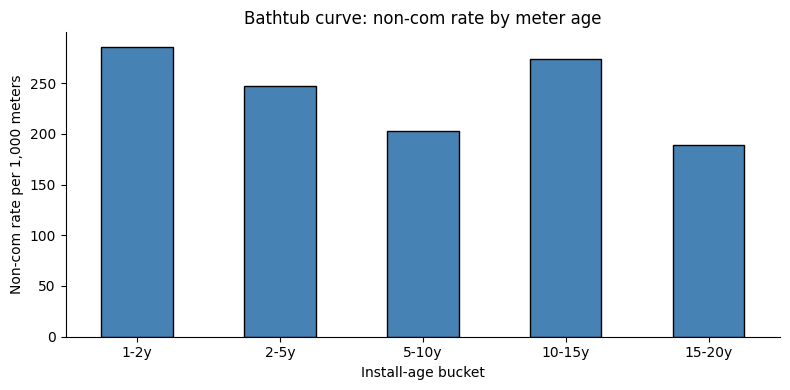

In [17]:
bathtub = non_com_rate_by_install_age(
    meters, events,
    install_date_col='install_date',
    age_buckets_years=(0, 1, 2, 5, 10, 15, 20),
    as_of_date='2026-04-26',
)
print(bathtub)

ax = bathtub['rate_per_1k'].plot(kind='bar', figsize=(8, 4), color='steelblue',
                                  edgecolor='black')
ax.set_ylabel('Non-com rate per 1,000 meters')
ax.set_xlabel('Install-age bucket')
ax.set_title('Bathtub curve: non-com rate by meter age')
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '07_bathtub_curve.png', dpi=150, bbox_inches='tight')
plt.show()


### 7e. 2D pivot — hardware model × install-age age

In [18]:
pivot = hardware_model_x_age(
    meters, events,
    age_buckets_years=(0, 2, 5, 10, 20),
    min_cell_meters=10,
    as_of_date='2026-04-26',
)
print('Failure rate per 1,000 meters (model × age):')
print(pivot)


Failure rate per 1,000 meters (model × age):
_age_bucket     0-2y    2-5y   5-10y  10-20y  20-infy
hardware_model                                       
ModelA-v1        NaN  228.57  216.67  191.78      NaN
ModelA-v2        NaN  210.53  146.34  216.67      NaN
ModelB           NaN  176.47  236.84  326.53      NaN
ModelC           NaN  222.22  100.00  375.00      NaN
ModelD-legacy    NaN     NaN     NaN     NaN      NaN


### 7f. Time-to-first-failure distribution

Mean years to first non-com: 7.96
Median years to first non-com: 8.68


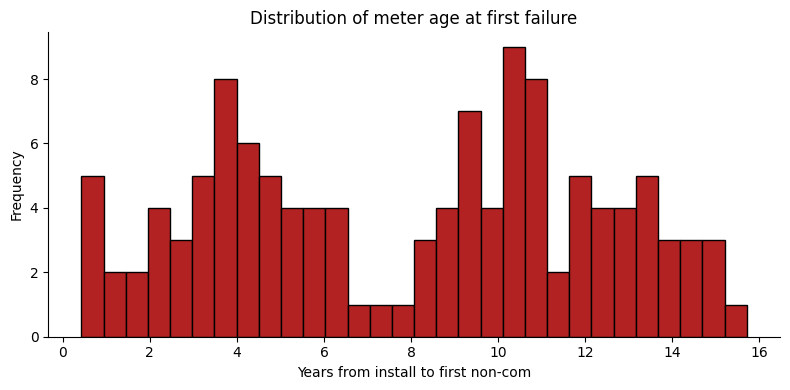

In [19]:
ttf = time_to_first_failure(meters, events)
print(f'Mean years to first non-com: {ttf["years_to_failure"].mean():.2f}')
print(f'Median years to first non-com: {ttf["years_to_failure"].median():.2f}')

ax = ttf['years_to_failure'].plot(kind='hist', bins=30, figsize=(8, 4),
                                   color='firebrick', edgecolor='black')
ax.set_xlabel('Years from install to first non-com')
ax.set_title('Distribution of meter age at first failure')
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '08_time_to_first_failure.png', dpi=150, bbox_inches='tight')
plt.show()


## Step 8: Pulling it together for the deck

By this point you have:

- **Lift table** showing which event types are over-represented before non-coms
- **Funnel headline** — "meters with X+ outages in 30 days are Yx more likely
  to go non-com in the next 60 days"
- **Hardware model breakout** — which models are the worst offenders
- **Bathtub curve** — at what age meters are most likely to fail
- **Eight saved figures** in `./figures/` ready for PowerPoint

A reasonable boss-deck slide order:

1. **The story in one chart**: Pre-failure signature plot — "events spike in
   the 30 days before failure"
2. **The story in numbers**: The funnel headline as a single big stat
3. **What this looks like for one meter**: Anatomy timeline (failed vs healthy)
4. **Where the failures live**: Hardware-model bar, then county choropleth
5. **When they happen**: Bathtub curve + calendar heatmap
6. **What we recommend**: Concrete actions (e.g., "preemptively replace ModelD
   meters older than X years"; "investigate any meter with 3+ outages in a
   rolling 30-day window")

Things you can add later:
- Pre-failure signal in **RSSI / signal strength** (often the single best
  predictor)
- **Firmware-version-at-time-of-non-com** breakout
- Power-quality / voltage breakouts
- Lightning strike data overlay
